In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [17]:
data = {
    "Year": [2019, 2020, 2021, 2022, 2023],

    "Mean_Probability": [
        0.028098194,
        0.038819492,
        0.029070187,
        0.027550494,
        0.03103549
    ],

    "Very_Low": [
        10584230,
        10401174,
        10545356,
        10598471,
        10557150
    ],

    "Low": [
        41443,
        147894,
        97320,
        34308,
        40104
    ],

    "Moderate": [
        30181,
        49295,
        39733,
        26400,
        33830
    ],

    "High": [
        36791,
        31108,
        45215,
        45519,
        37912
    ],

    "Very_High": [
        158891,
        222065,
        123912,
        146838,
        182540
    ]
}

temporal_df = pd.DataFrame(data)

temporal_df

,Year,Mean_Probability,Very_Low,Low,Moderate,High,Very_High
0,2019,0.028098,10584230,41443,30181,36791,158891
1,2020,0.038819,10401174,147894,49295,31108,222065
2,2021,0.029070,10545356,97320,39733,45215,123912
3,2022,0.027550,10598471,34308,26400,45519,146838
4,2023,0.031035,10557150,40104,33830,37912,182540


In [18]:
class_columns = [
    "Very_Low",
    "Low",
    "Moderate",
    "High",
    "Very_High"
]

total_pixels = temporal_df[class_columns].sum(axis=1)

for col in class_columns:
    temporal_df[col + "_Percent"] = (
        temporal_df[col] / total_pixels * 100
    )

temporal_df

,Year,Mean_Probability,Very_Low,Low,Moderate,High,Very_High,Very_Low_Percent,Low_Percent,Moderate_Percent,High_Percent,Very_High_Percent
0,2019,0.028098,10584230,41443,30181,36791,158891,97.536699,0.381909,0.278127,0.339040,1.464226
1,2020,0.038819,10401174,147894,49295,31108,222065,95.849786,1.362885,0.454267,0.286669,2.046392
2,2021,0.029070,10545356,97320,39733,45215,123912,97.178464,0.896832,0.366151,0.416669,1.141884
3,2022,0.027550,10598471,34308,26400,45519,146838,97.667934,0.316158,0.243284,0.419471,1.353154
4,2023,0.031035,10557150,40104,33830,37912,182540,97.287149,0.369570,0.311753,0.349370,1.682158


In [19]:
summary_df = temporal_df[
    [
        "Year",
        "Mean_Probability",
        "Very_Low_Percent",
        "Low_Percent",
        "Moderate_Percent",
        "High_Percent",
        "Very_High_Percent"
    ]
].copy()

summary_df

,Year,Mean_Probability,Very_Low_Percent,Low_Percent,Moderate_Percent,High_Percent,Very_High_Percent
0,2019,0.028098,97.536699,0.381909,0.278127,0.339040,1.464226
1,2020,0.038819,95.849786,1.362885,0.454267,0.286669,2.046392
2,2021,0.029070,97.178464,0.896832,0.366151,0.416669,1.141884
3,2022,0.027550,97.667934,0.316158,0.243284,0.419471,1.353154
4,2023,0.031035,97.287149,0.369570,0.311753,0.349370,1.682158


In [20]:
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

summary_path = os.path.join(
    RESULTS_DIR,
    "temporal_susceptibility_summary_2019_2023.csv"
)

summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\temporal_susceptibility_summary_2019_2023.csv


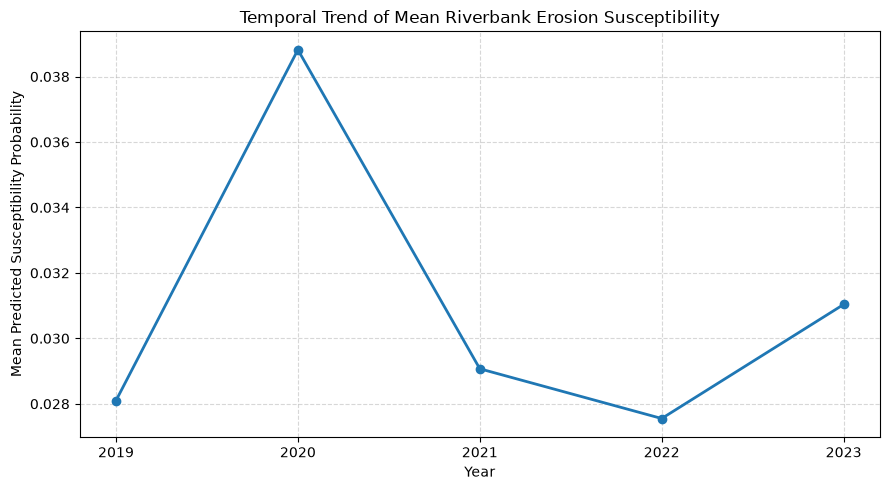

Saved: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\temporal_mean_susceptibility_2019_2023.png


In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    temporal_df["Year"],
    temporal_df["Mean_Probability"],
    marker="o",
    linewidth=2
)

plt.title("Temporal Trend of Mean Riverbank Erosion Susceptibility")
plt.xlabel("Year")
plt.ylabel("Mean Predicted Susceptibility Probability")
plt.xticks(temporal_df["Year"])
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

output_path = os.path.join(
    RESULTS_DIR,
    "temporal_mean_susceptibility_2019_2023.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

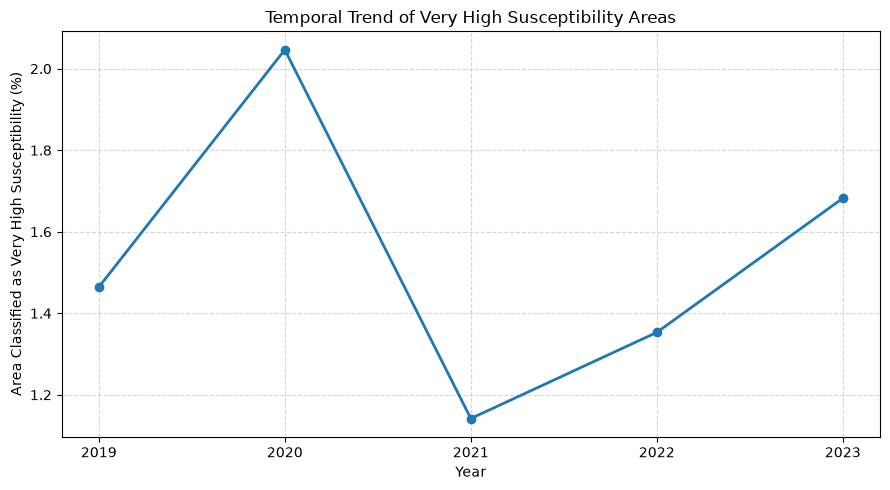

Saved: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\temporal_very_high_susceptibility_2019_2023.png


In [22]:
plt.figure(figsize=(9, 5))

plt.plot(
    temporal_df["Year"],
    temporal_df["Very_High_Percent"],
    marker="o",
    linewidth=2
)

plt.title("Temporal Trend of Very High Susceptibility Areas")
plt.xlabel("Year")
plt.ylabel("Area Classified as Very High Susceptibility (%)")
plt.xticks(temporal_df["Year"])
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

output_path = os.path.join(
    RESULTS_DIR,
    "temporal_very_high_susceptibility_2019_2023.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

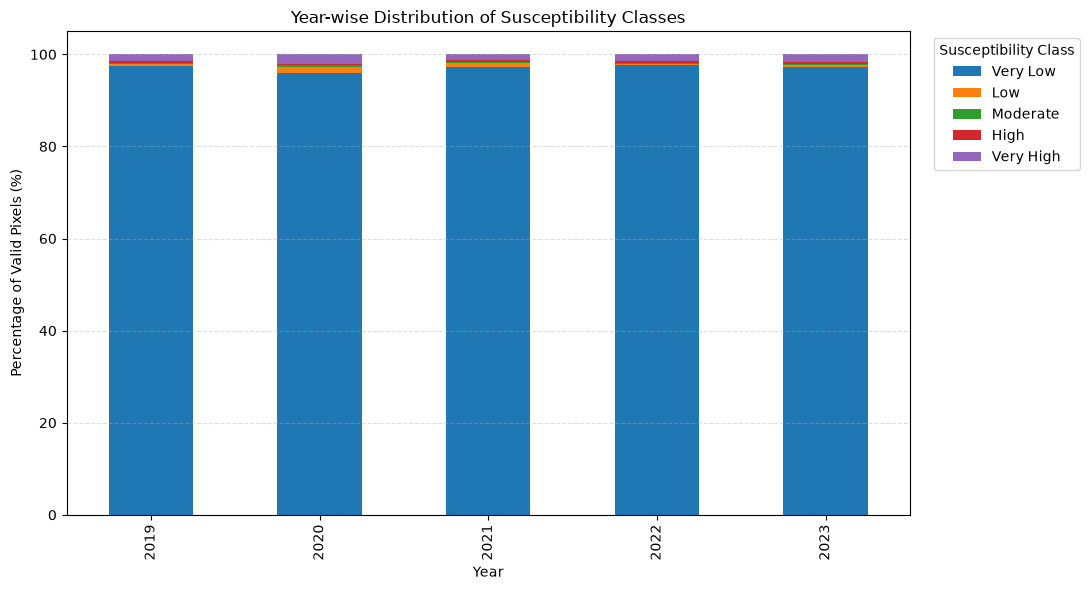

Saved: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\temporal_susceptibility_class_distribution.png


In [23]:
class_percent_columns = [
    "Very_Low_Percent",
    "Low_Percent",
    "Moderate_Percent",
    "High_Percent",
    "Very_High_Percent"
]

plot_df = temporal_df.set_index("Year")[class_percent_columns].copy()

plot_df.columns = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

ax.set_title("Year-wise Distribution of Susceptibility Classes")
ax.set_xlabel("Year")
ax.set_ylabel("Percentage of Valid Pixels (%)")
ax.legend(title="Susceptibility Class", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

output_path = os.path.join(
    RESULTS_DIR,
    "temporal_susceptibility_class_distribution.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

In [25]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

prob_2019_path = os.path.join(
    RESULTS_DIR,
    "Mahanadi_Susceptibility_2019_Probability.tif"
)

prob_2023_path = os.path.join(
    RESULTS_DIR,
    "Mahanadi_Susceptibility_2023_Probability.tif"
)

with rasterio.open(prob_2019_path) as src_2019:
    prob_2019 = src_2019.read(1)
    profile_2019 = src_2019.profile.copy()
    transform_2019 = src_2019.transform
    crs_2019 = src_2019.crs
    nodata_2019 = src_2019.nodata

with rasterio.open(prob_2023_path) as src_2023:
    prob_2023 = src_2023.read(1)
    profile_2023 = src_2023.profile.copy()
    transform_2023 = src_2023.transform
    crs_2023 = src_2023.crs
    nodata_2023 = src_2023.nodata

print("2019 raster shape:", prob_2019.shape)
print("2023 raster shape:", prob_2023.shape)
print("2019 CRS:", crs_2019)
print("2023 CRS:", crs_2023)
print("2019 transform:", transform_2019)
print("2023 transform:", transform_2023)

2019 raster shape: (2785, 3898)
2023 raster shape: (2785, 3898)
2019 CRS: EPSG:4326
2023 CRS: EPSG:4326
2019 transform: | 0.00, 0.00, 83.85|
| 0.00,-0.00, 21.60|
| 0.00, 0.00, 1.00|
2023 transform: | 0.00, 0.00, 83.85|
| 0.00,-0.00, 21.60|
| 0.00, 0.00, 1.00|


In [26]:
assert prob_2019.shape == prob_2023.shape, "Raster dimensions differ!"
assert crs_2019 == crs_2023, "CRS differs!"
assert transform_2019 == transform_2023, "Pixel alignment differs!"

print("Raster dimensions, CRS, and pixel alignment match.")

Raster dimensions, CRS, and pixel alignment match.


In [27]:
valid_mask = (
    np.isfinite(prob_2019) &
    np.isfinite(prob_2023)
)

if nodata_2019 is not None:
    valid_mask &= prob_2019 != nodata_2019

if nodata_2023 is not None:
    valid_mask &= prob_2023 != nodata_2023

change = np.full(prob_2019.shape, np.nan, dtype=np.float32)

change[valid_mask] = (
    prob_2023[valid_mask] - prob_2019[valid_mask]
)

print("Valid pixels:", int(valid_mask.sum()))
print("Minimum change:", float(np.nanmin(change)))
print("Maximum change:", float(np.nanmax(change)))
print("Mean change:", float(np.nanmean(change)))

Valid pixels: 10851536
Minimum change: -1.0
Maximum change: 1.0
Mean change: 0.0029372957069426775


In [28]:
change_path = os.path.join(
    RESULTS_DIR,
    "Mahanadi_Susceptibility_Change_2019_2023.tif"
)

change_profile = profile_2019.copy()
change_profile.update(
    dtype="float32",
    count=1,
    nodata=-9999.0,
    compress="lzw"
)

change_to_save = np.where(
    valid_mask,
    change,
    -9999.0
).astype(np.float32)

with rasterio.open(change_path, "w", **change_profile) as dst:
    dst.write(change_to_save, 1)
    dst.set_band_description(
        1, "Probability change: 2023 minus 2019"
    )

print("Saved change raster:", change_path)

Saved change raster: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\Mahanadi_Susceptibility_Change_2019_2023.tif


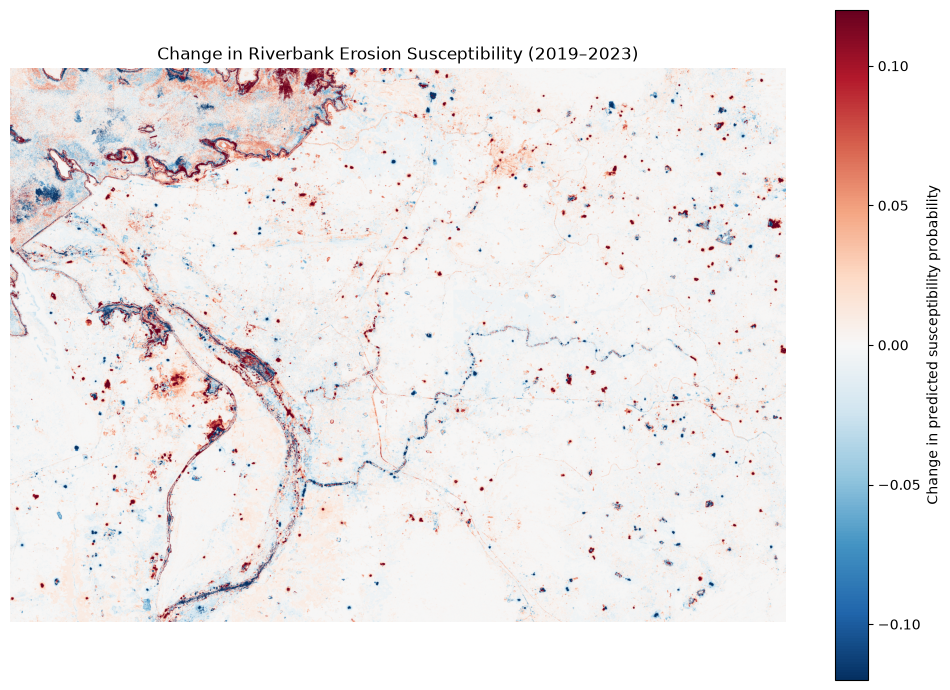

Saved change map: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\Mahanadi_Susceptibility_Change_2019_2023.png


In [29]:
limit = np.nanpercentile(np.abs(change[valid_mask]), 98)

plt.figure(figsize=(10, 7))

image = plt.imshow(
    change,
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit
)

plt.colorbar(
    image,
    label="Change in predicted susceptibility probability"
)

plt.title("Change in Riverbank Erosion Susceptibility (2019–2023)")
plt.axis("off")
plt.tight_layout()

map_path = os.path.join(
    RESULTS_DIR,
    "Mahanadi_Susceptibility_Change_2019_2023.png"
)

plt.savefig(map_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved change map:", map_path)

In [30]:
# Change categories based on probability difference
INCREASE_THRESHOLD = 0.05
DECREASE_THRESHOLD = -0.05

increase_mask = valid_mask & (change > INCREASE_THRESHOLD)
decrease_mask = valid_mask & (change < DECREASE_THRESHOLD)
stable_mask = (
    valid_mask
    & (change >= DECREASE_THRESHOLD)
    & (change <= INCREASE_THRESHOLD)
)

total_valid = int(valid_mask.sum())

change_summary = pd.DataFrame({
    "Change_Category": [
        "Increased susceptibility",
        "Nearly unchanged susceptibility",
        "Decreased susceptibility"
    ],
    "Pixel_Count": [
        int(increase_mask.sum()),
        int(stable_mask.sum()),
        int(decrease_mask.sum())
    ]
})

change_summary["Percentage"] = (
    change_summary["Pixel_Count"] / total_valid * 100
)

change_summary

,Change_Category,Pixel_Count,Percentage
0,Increased susceptibility,317488,2.925742
1,Nearly unchanged susceptibility,10324107,95.139591
2,Decreased susceptibility,209941,1.934666


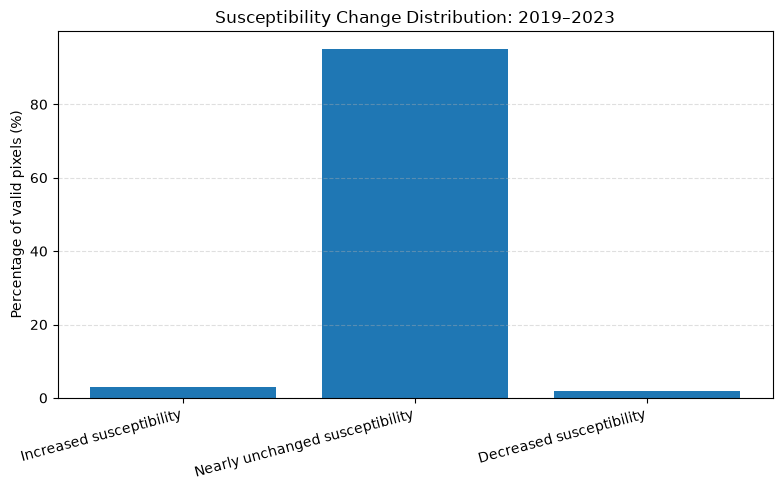

Saved: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\susceptibility_change_distribution_2019_2023.png


In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    change_summary["Change_Category"],
    change_summary["Percentage"]
)

plt.ylabel("Percentage of valid pixels (%)")
plt.title("Susceptibility Change Distribution: 2019–2023")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

change_distribution_path = os.path.join(
    RESULTS_DIR,
    "susceptibility_change_distribution_2019_2023.png"
)

plt.savefig(change_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", change_distribution_path)

In [32]:
change_summary_path = os.path.join(
    RESULTS_DIR,
    "susceptibility_change_summary_2019_2023.csv"
)

change_summary.to_csv(change_summary_path, index=False)

print("Saved:", change_summary_path)

Saved: c:\Users\salon\OneDrive\ドキュメント\ml_miniproject\results\susceptibility_change_summary_2019_2023.csv
